## Celda 1: Carga, Limpieza, Diccionarios e Integración

In [57]:
import pandas as pd
import numpy as np
import os

# -----------------------------------------------------------------------------
# 0. CONFIGURACIÓN DE RUTAS
# -----------------------------------------------------------------------------
DIR_PARQUET = os.path.join("..", "data", "datos_normalizados_parquet")

if not os.path.exists(DIR_PARQUET):
    raise FileNotFoundError(f"No se encontró el directorio: {os.path.abspath(DIR_PARQUET)}")

# -----------------------------------------------------------------------------
# 1. CARGA Y LIMPIEZA DE ENCABEZADOS
# -----------------------------------------------------------------------------
ruta_1631 = os.path.join(DIR_PARQUET, "1036-Modulo1631.parquet")
ruta_1638 = os.path.join(DIR_PARQUET, "1036-Modulo1638.parquet")

df_1631 = pd.read_parquet(ruta_1631)
df_1638 = pd.read_parquet(ruta_1638)

# Limpieza estandarizada de columnas
df_1631.columns = df_1631.columns.str.replace('ï»¿', '', regex=False).str.strip().str.lower()
df_1638.columns = df_1638.columns.str.replace('ï»¿', '', regex=False).str.strip().str.lower()

print(f" Filas Módulo 1631 (Hogar/Madre): {len(df_1631):,}")
print(f" Filas Módulo 1638 (Antropometría/HW): {len(df_1638):,}")

# -----------------------------------------------------------------------------
# 2. DICCIONARIOS DE DATOS (Módulos 1638 y 1631)
# -----------------------------------------------------------------------------
dicc_anemia_nivel = {
    1: '1. Grave',
    2: '2. Moderada',
    3: '3. Leve',
    4: '4. Sin Anemia'
}

# Diccionario según imagen: Logro educativo (V149)
dicc_logro_educativo = {
    0: '0. Sin educación',
    1: '1. Primaria incompleta',
    2: '2. Primaria completa',
    3: '3. Secundaria incompleta',
    4: '4. Secundaria completa',
    5: '5. Superior'
}

# Diccionario según imagen: Relación con el jefe del hogar (V150)
dicc_relacion_jefe = {
    1: '1. Jefe del hogar',
    2: '2. Esposa/Esposo',
    3: '3. Hijo/Hija',
    4: '4. Yerno/Nuera',
    5: '5. Nieto/Nieta',
    6: '6. Padre/Madre',
    7: '7. Suegro/Suegra',
    8: '8. Hermano/a',
    9: '9. Conviviente',
    10: '10. Otro pariente',
    11: '11. Hijo adoptado/de crianza',
    12: '12. Sin parentesco',
    15: '15. Empleada doméstica',
    98: '98. No sabe'
}

# Diccionario según imagen: Sexo del jefe del hogar (V151)
dicc_sexo_jefe = {
    1: '1. Hombre',
    2: '2. Mujer'
}

# -----------------------------------------------------------------------------
# 3. EXTRACCIÓN Y PREPARACIÓN DE VARIABLES EN MÓDULO 1631
# -----------------------------------------------------------------------------
df_1631['caseid'] = df_1631['caseid'].astype(str)
df_1638['caseid'] = df_1638['caseid'].astype(str)

# Lista de variables sociodemográficas y de educación a incorporar
cols_deseadas_1631 = ['caseid', 'ubigeo', 'v190', 'v149', 'v150', 'v151', 'v152']
cols_1631 = [col for col in cols_deseadas_1631 if col in df_1631.columns]

# Extraemos solo las columnas necesarias sin duplicados por llave 'caseid'
df_1631_subset = df_1631[cols_1631].drop_duplicates(subset=['caseid'])

# -----------------------------------------------------------------------------
# 4. CRUCE (INTEGRACIÓN DE TABLAS)
# -----------------------------------------------------------------------------
df_merged = pd.merge(
    df_1638,
    df_1631_subset,
    on='caseid',
    how='inner'
)

# -----------------------------------------------------------------------------
# 5. MAPEADO Y CREACIÓN DE CAMPOS ENRIQUECIDOS (DESCRIPTIVOS)
# -----------------------------------------------------------------------------
# Orden del niño
if 'hwidx' in df_merged.columns:
    df_merged['orden_niño'] = pd.to_numeric(df_merged['hwidx'], errors='coerce')

# Logro Educativo de la Madre/Entrevistada
if 'v149' in df_merged.columns:
    df_merged['v149_num'] = pd.to_numeric(df_merged['v149'], errors='coerce')
    df_merged['desc_logro_educativo'] = df_merged['v149_num'].map(dicc_logro_educativo).fillna('No Especificado')

# Relación con el Jefe del Hogar
if 'v150' in df_merged.columns:
    df_merged['v150_num'] = pd.to_numeric(df_merged['v150'], errors='coerce')
    df_merged['desc_relacion_jefe'] = df_merged['v150_num'].map(dicc_relacion_jefe).fillna('Otro/Desconocido')

# Sexo del Jefe del Hogar
if 'v151' in df_merged.columns:
    df_merged['v151_num'] = pd.to_numeric(df_merged['v151'], errors='coerce')
    df_merged['desc_sexo_jefe'] = df_merged['v151_num'].map(dicc_sexo_jefe).fillna('No Especificado')

# Edad del Jefe del Hogar
if 'v152' in df_merged.columns:
    df_merged['edad_jefe_hogar'] = pd.to_numeric(df_merged['v152'], errors='coerce')

print(f" Cruce exitoso. Registros vinculados: {len(df_merged):,}")
print(f" Nuevas variables integradas: {[c for c in ['desc_logro_educativo', 'desc_relacion_jefe', 'desc_sexo_jefe', 'edad_jefe_hogar'] if c in df_merged.columns]}")

 Filas Módulo 1631 (Hogar/Madre): 36,260
 Filas Módulo 1638 (Antropometría/HW): 18,841
 Cruce exitoso. Registros vinculados: 18,841
 Nuevas variables integradas: ['desc_logro_educativo', 'desc_relacion_jefe', 'desc_sexo_jefe', 'edad_jefe_hogar']


## Celda 2: TÉCNICA 1 - Variables Derivadas

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# APLICACIÓN DE LA TÉCNICA DE VARIABLES DERIVADAS
# -----------------------------------------------------------------------------
# a) Presencia y Nivel de Anemia (Módulo 1638 - REC44)
# -----------------------------------------------------------------------------
if 'hw57' in df_merged.columns:
    hw57_num = pd.to_numeric(df_merged['hw57'], errors='coerce')
    df_merged['tiene_anemia'] = np.where(hw57_num.isin([1, 2, 3]), 1, 0)
    df_merged['desc_anemia_nivel'] = hw57_num.map(dicc_anemia_nivel).fillna('Sin dato')
else:
    df_merged['tiene_anemia'] = 0
    df_merged['desc_anemia_nivel'] = 'Sin dato'
    
# -----------------------------------------------------------------------------
# b) Orden de Nacimiento Categorizado (Basado en hwidx del Módulo 1638)
# -----------------------------------------------------------------------------
orden_num = df_merged['orden_niño']
df_merged['tipo_orden_nacimiento'] = np.where(
    orden_num == 1, 
    '1. Primogénito', 
    np.where(orden_num <= 3, '2. Segundo/Tercer Hijo', '3. Cuarto a más')
)

# -----------------------------------------------------------------------------
# c) DERIVADA 1: Nivel Educativo Agrupado de la Madre (v149)
# -----------------------------------------------------------------------------
if 'v149_num' in df_merged.columns:
    # 1. Mapeo descriptivo original detallado (0 a 5)
    df_merged['desc_logro_educativo'] = df_merged['v149_num'].map(dicc_logro_educativo).fillna('No Especificado')
    
    # 2. Variable Derivada Agrupada en 4 Niveles Educativos
    condiciones_educacion = [
        (df_merged['v149_num'] == 0),                             # 0: Sin educación
        (df_merged['v149_num'].isin([1, 2])),                     # 1 o 2: Primaria
        (df_merged['v149_num'].isin([3, 4])),                     # 3 o 4: Secundaria
        (df_merged['v149_num'] == 5)                              # 5: Superior
    ]
    
    etiquetas_educacion = [
        '1. Sin Educación',
        '2. Primaria (Completa e Incompleta)',
        '3. Secundaria (Completa e Incompleta)',
        '4. Superior'
    ]
    
    # Aplicación de la agrupación vectorizada
    df_merged['nivel_educativo_agrupado'] = np.select(
        condiciones_educacion, 
        etiquetas_educacion, 
        default='No Especificado'
    )

# -----------------------------------------------------------------------------
# d) DERIVADA 2: Jefatura del Hogar Femenina (v151)
# -----------------------------------------------------------------------------
if 'v151_num' in df_merged.columns:
    df_merged['desc_sexo_jefe'] = df_merged['v151_num'].map(dicc_sexo_jefe).fillna('No Especificado')
    
    # Flag binario para análisis de género
    df_merged['es_jefatura_femenina'] = np.where(df_merged['v151_num'] == 2, 1, 0)


# -----------------------------------------------------------------------------
# e) DERIVADA 3: Rango de Edad del Jefe de Hogar (v152)
# -----------------------------------------------------------------------------
if 'edad_jefe_hogar' in df_merged.columns:
    edad_jefe = df_merged['edad_jefe_hogar']
    
    conditions = [
        (edad_jefe < 20),                                 # Menor a 20 años
        (edad_jefe >= 20) & (edad_jefe < 30),             # Entre 20 y 29 años
        (edad_jefe >= 30) & (edad_jefe < 60),             # Entre 30 y 59 años
        (edad_jefe >= 60)                                 # 60 años a más
    ]
    
    choices = [
        '1. Muy Joven (<20 años)',
        '2. Joven (20-29 años)',
        '3. Adulto (30-59 años)',
        '4. Adulto Mayor (60+ años)'
    ]
    
    df_merged['rango_edad_jefe_hogar'] = np.select(
        conditions, 
        choices, 
        default='No Especificado'
    )
# -----------------------------------------------------------------------------
# f) Descripciones complementarias (v150)
# -----------------------------------------------------------------------------
if 'v150_num' in df_merged.columns:
    df_merged['desc_relacion_jefe'] = df_merged['v150_num'].map(dicc_relacion_jefe).fillna('Otro/Desconocido')

print(" Aplicación de Técnica 1 (Variables Derivadas) completada exitosamente.")



 Aplicación de Técnica 1 (Variables Derivadas) completada exitosamente.


## TÉCNICA 2 - Agregaciones Históricas 

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# TÉCNICA 2: AGREGACIONES HISTÓRICAS Y CONTEXTUALES
# =============================================================================

# -----------------------------------------------------------------------------
# 1. BASE TERRITORIAL (Código y Nombre de Departamento)
# -----------------------------------------------------------------------------
if 'ubigeo' in df_merged.columns:
    df_merged['codigo_dep'] = df_merged['ubigeo'].astype(str).str.zfill(6).str[:2]
else:
    df_merged['codigo_dep'] = '15' # Valor por defecto

dicc_departamentos = {
    '01': 'Amazonas', '02': 'Áncash', '03': 'Apurímac', '04': 'Arequipa', '05': 'Ayacucho',
    '06': 'Cajamarca', '07': 'Callao', '08': 'Cusco', '09': 'Huancavelica', '10': 'Huánuco',
    '11': 'Ica', '12': 'Junín', '13': 'La Libertad', '14': 'Lambayeque', '15': 'Lima',
    '16': 'Loreto', '17': 'Madre de Dios', '18': 'Moquegua', '19': 'Pasco', '20': 'Piura',
    '21': 'Puno', '22': 'San Martín', '23': 'Tacna', '24': 'Tumbes', '25': 'Ucayali'
}

df_merged['nombre_departamento'] = df_merged['codigo_dep'].map(dicc_departamentos).fillna('Otros/Desconocido')

# -----------------------------------------------------------------------------
# 2. CASO 1 (SE MANTIENE): Agregación Territorial Departamental
# -----------------------------------------------------------------------------
df_merged['total_evaluados_dep'] = df_merged.groupby('codigo_dep')['caseid'].transform('count')
df_merged['total_anemia_dep'] = df_merged.groupby('codigo_dep')['tiene_anemia'].transform('sum')
df_merged['pct_anemia_dep'] = (df_merged['total_anemia_dep'] / df_merged['total_evaluados_dep']) * 100

# -----------------------------------------------------------------------------
# 3. CASO 2 (NUEVO): Agregación Socioeducativa por Departamento
# -----------------------------------------------------------------------------
if 'nivel_educativo_agrupado' in df_merged.columns:
    # Cuenta evaluados y casos de anemia según el nivel educativo dentro de cada departamento
    group_dep_edu = df_merged.groupby(['codigo_dep', 'nivel_educativo_agrupado'])
    
    df_merged['evaluados_dep_edu'] = group_dep_edu['caseid'].transform('count')
    df_merged['anemia_dep_edu'] = group_dep_edu['tiene_anemia'].transform('sum')
    df_merged['pct_anemia_dep_edu'] = (df_merged['anemia_dep_edu'] / df_merged['evaluados_dep_edu']) * 100

# -----------------------------------------------------------------------------
# 4. CASO 3 (NUEVO): Agregación por Quintil de Riqueza (v190)
# -----------------------------------------------------------------------------
if 'v190' in df_merged.columns:
    group_riqueza = df_merged.groupby('v190')
    df_merged['pct_anemia_quintil_riqueza'] = group_riqueza['tiene_anemia'].transform('mean') * 100

# -----------------------------------------------------------------------------
# 5. CASO 4: Promedio Clínico por Rango de Edad en Meses
# -----------------------------------------------------------------------------
if 'hw1' in df_merged.columns and 'hw56' in df_merged.columns:
    # 1. Convertir edad en meses a tipo numérico (0-59)
    df_merged['edad_meses_num'] = pd.to_numeric(df_merged['hw1'], errors='coerce')
    
    # 2. Convertir hemoglobina ajustada por altitud a g/dl (numérico)
    hb_num = pd.to_numeric(df_merged['hw56'], errors='coerce') / 10.0
    
    # 3. Calcular el promedio por grupo de edad directamente sobre la Serie numérica
    df_merged['prom_hb_edad_meses'] = hb_num.groupby(df_merged['edad_meses_num']).transform('mean')

print(" Agregaciones históricas y contextuales calculadas con éxito.")



 Agregaciones históricas y contextuales calculadas con éxito.


## TÉCNICA 3 - Transformación por Rangos (Binning / Discretización)

In [60]:
# =============================================================================
# TÉCNICA 3: TRANSFORMACIÓN POR RANGOS (BINNING / DISCRETIZACIÓN)
# =============================================================================

# -----------------------------------------------------------------------------
# a) CASO 1 (EXISTENTE): Rangos de Edad en Meses del Niño (hw1)
# -----------------------------------------------------------------------------
if 'hw1' in df_merged.columns:
    hw1_num = pd.to_numeric(df_merged['hw1'], errors='coerce')
    rangos_edad = [0, 11, 23, 59]
    etiquetas_edad = [
        '1. 0-11 meses (Lactantes)', 
        '2. 12-23 meses (Caminadores)', 
        '3. 24-59 meses (Preescolares)'
    ]
    
    df_merged['rango_edad_child'] = pd.cut(
        hw1_num, 
        bins=rangos_edad, 
        labels=etiquetas_edad, 
        include_lowest=True
    )

# -----------------------------------------------------------------------------
# b) CASO 2 (EXISTENTE): Hemoglobina Ajustada por Altitud (hw56: g/dL x 10)
# -----------------------------------------------------------------------------
if 'hw56' in df_merged.columns:
    df_merged['hemoglobina_g_dl'] = pd.to_numeric(df_merged['hw56'], errors='coerce') / 10.0
    rangos_hb = [0.0, 6.9, 9.9, 10.9, 25.0]
    etiquetas_hb = [
        '1. Anemia Severa (<7.0 g/dL)', 
        '2. Anemia Moderada (7.0-9.9 g/dL)', 
        '3. Anemia Leve (10.0-10.9 g/dL)', 
        '4. Sin Anemia (>=11.0 g/dL)'
    ]
    
    df_merged['rango_hemoglobina'] = pd.cut(
        df_merged['hemoglobina_g_dl'], 
        bins=rangos_hb, 
        labels=etiquetas_hb,
        include_lowest=True
    )

# -----------------------------------------------------------------------------
# c) CASO 3 (NUEVO): Estado Nutricional Talla/Edad - Desnutrición Crónica (hw70)
# -----------------------------------------------------------------------------
if 'hw70' in df_merged.columns:
    # hw70 viene en desviaciones estándar x 100 (ejemplo: -200 = -2.0 DE)
    z_talla_edad = pd.to_numeric(df_merged['hw70'], errors='coerce') / 100.0
    
    # Bins oficiales OMS para puntuación Z
    rangos_z = [-6.0, -3.01, -2.01, 2.0, 6.0]
    etiquetas_z = [
        '1. Desnutrición Crónica Severa (<-3 DE)',
        '2. Desnutrición Crónica Moderada (-3 a -2 DE)',
        '3. Talla Normal (-2 a +2 DE)',
        '4. Talla Alta (>+2 DE)'
    ]
    
    df_merged['rango_desnutricion_cronica'] = pd.cut(
        z_talla_edad,
        bins=rangos_z,
        labels=etiquetas_z
    )
    
# -----------------------------------------------------------------------------
# d) CASO 4 (REEMPLAZO): Estado Nutricional Peso/Talla - Emaciación / Sobrepeso (hw72)
# -----------------------------------------------------------------------------
if 'hw72' in df_merged.columns:
    # hw72 viene en desviaciones estándar x 100 (ejemplo: -200 = -2.0 DE)
    z_peso_talla = pd.to_numeric(df_merged['hw72'], errors='coerce') / 100.0
    
    # Bins oficiales OMS para Peso para la Talla / IMC
    rangos_pt = [-6.0, -2.01, 2.0, 3.0, 6.0]
    etiquetas_pt = [
        '1. Desnutrición Aguda / Emaciación (<-2 DE)',
        '2. Peso Normal (-2 a +2 DE)',
        '3. Sobrepeso (+2 a +3 DE)',
        '4. Obesidad Infantil (>+3 DE)'
    ]
    
    df_merged['rango_peso_talla_oms'] = pd.cut(
        z_peso_talla,
        bins=rangos_pt,
        labels=etiquetas_pt
    )    

print(" Transformación por Rangos (Binning / Discretización) calculadas con éxito.")



 Transformación por Rangos (Binning / Discretización) calculadas con éxito.


In [61]:
import pandas as pd
import numpy as np

# =============================================================================
# RESUMEN GENERAL Y CONTEO COMPLETO DE VARIABLES (TÉCNICAS 1, 2, 3 Y 4)
# =============================================================================

# Matriz detallada de trazabilidad de variables actualizada
matriz_resumen = pd.DataFrame([
    # --- VARIABLES ORIGINALES USADAS ---
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'caseid', 'Modulo Origen': 'M1631 / M1638', 'Tecnica Aplicada': 'Llave Primaria', 'Descripcion / Valor de Negocio': 'Identificador único de la madre y el hogar.'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'hwidx / orden_niño', 'Modulo Origen': 'M1638 (HW)', 'Tecnica Aplicada': 'Llave Primaria', 'Descripcion / Valor de Negocio': 'Número de línea u orden de nacimiento del hijo.'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'hw1', 'Modulo Origen': 'M1638 (HW)', 'Tecnica Aplicada': 'Original (Edad)', 'Descripcion / Valor de Negocio': 'Edad del niño registrada en meses (0-59).'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'hw56', 'Modulo Origen': 'M1638 (HW)', 'Tecnica Aplicada': 'Original (Hemoglobina)', 'Descripcion / Valor de Negocio': 'Hemoglobina ajustada por altitud (expresada x10).'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'hw57', 'Modulo Origen': 'M1638 (HW)', 'Tecnica Aplicada': 'Original (Anemia)', 'Descripcion / Valor de Negocio': 'Nivel de anemia (1=Grave, 2=Mod, 3=Leve, 4=Sin Anemia).'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'hw70', 'Modulo Origen': 'M1638 (HW)', 'Tecnica Aplicada': 'Original (Talla/Edad)', 'Descripcion / Valor de Negocio': 'Desviación estándar de Talla para la Edad (OMS x100).'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'hw72', 'Modulo Origen': 'M1638 (HW)', 'Tecnica Aplicada': 'Original (Peso/Talla)', 'Descripcion / Valor de Negocio': 'Desviación estándar de Peso para la Talla (OMS x100).'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'ubigeo', 'Modulo Origen': 'M1631 (REC0111)', 'Tecnica Aplicada': 'Original (Ubicación)', 'Descripcion / Valor de Negocio': 'Código de ubicación geográfica distrital (6 dígitos).'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'v149', 'Modulo Origen': 'M1631 (REC0111)', 'Tecnica Aplicada': 'Original (Educación)', 'Descripcion / Valor de Negocio': 'Nivel educativo de la madre (0 a 5).'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'v150', 'Modulo Origen': 'M1631 (REC0111)', 'Tecnica Aplicada': 'Original (Parentesco)', 'Descripcion / Valor de Negocio': 'Relación de parentesco con el jefe del hogar.'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'v151', 'Modulo Origen': 'M1631 (REC0111)', 'Tecnica Aplicada': 'Original (Sexo Jefe)', 'Descripcion / Valor de Negocio': 'Sexo del jefe del hogar (1=Hombre, 2=Mujer).'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'v152', 'Modulo Origen': 'M1631 (REC0111)', 'Tecnica Aplicada': 'Original (Edad Jefe)', 'Descripcion / Valor de Negocio': 'Edad en años del jefe del hogar.'},
    {'Categoria': 'Variable Original Usada', 'Nombre Campo': 'v190', 'Modulo Origen': 'M1631 (REC0111)', 'Tecnica Aplicada': 'Original (Riqueza)', 'Descripcion / Valor de Negocio': 'Índice de quintil de riqueza (1=Poquísimo a 5=Ricazo).'},
    
    # --- NUEVAS VARIABLES CREADAS ---
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'tiene_anemia', 'Modulo Origen': 'M1638 (hw57)', 'Tecnica Aplicada': 'Técnica 1: Derivada (Flag)', 'Descripcion / Valor de Negocio': 'Indicador binario de anemia (1=Sí, 0=No).'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'tipo_orden_nacimiento', 'Modulo Origen': 'M1638 (hwidx)', 'Tecnica Aplicada': 'Técnica 1: Derivada (Regla)', 'Descripcion / Valor de Negocio': 'Clasificación: Primogénito, 2do/3er hijo, 4to a más.'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'nivel_educativo_agrupado', 'Modulo Origen': 'M1631 (v149)', 'Tecnica Aplicada': 'Técnica 1: Derivada (Agrupación)', 'Descripcion / Valor de Negocio': 'Nivel agrupado (Sin Ed, Primaria, Secundaria, Superior).'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'es_jefatura_femenina', 'Modulo Origen': 'M1631 (v151)', 'Tecnica Aplicada': 'Técnica 1: Derivada (Flag)', 'Descripcion / Valor de Negocio': 'Flag binario de jefatura del hogar femenina (1=Mujer, 0=Hombre).'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'rango_edad_jefe_hogar', 'Modulo Origen': 'M1631 (v152)', 'Tecnica Aplicada': 'Técnica 1: Derivada (Rangos)', 'Descripcion / Valor de Negocio': 'Grupos etarios del jefe (<20, 20-29, 30-59, 60+ años).'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'codigo_dep', 'Modulo Origen': 'M1631 (ubigeo)', 'Tecnica Aplicada': 'Técnica 2: Extracción (Subcadena)', 'Descripcion / Valor de Negocio': 'Dos primeros dígitos de Ubigeo para agrupar por departamento.'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'total_evaluados_dep', 'Modulo Origen': 'M1631 / M1638', 'Tecnica Aplicada': 'Técnica 2: Agregación Territorial', 'Descripcion / Valor de Negocio': 'Conteo total acumulado de niños evaluados por departamento.'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'total_anemia_dep', 'Modulo Origen': 'M1638', 'Tecnica Aplicada': 'Técnica 2: Agregación Territorial', 'Descripcion / Valor de Negocio': 'Suma acumulada de niños con anemia por departamento.'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'evaluados_dep_edu', 'Modulo Origen': 'M1631 / M1638', 'Tecnica Aplicada': 'Técnica 2: Agregación Socioeducativa', 'Descripcion / Valor de Negocio': 'Evaluados por departamento según nivel educativo materno.'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'anemia_dep_edu', 'Modulo Origen': 'M1631 / M1638', 'Tecnica Aplicada': 'Técnica 2: Agregación Socioeducativa', 'Descripcion / Valor de Negocio': 'Casos de anemia por departamento según educación materna.'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'pct_anemia_quintil_riqueza', 'Modulo Origen': 'M1631 (v190)', 'Tecnica Aplicada': 'Técnica 2: Agregación Socioeconómica', 'Descripcion / Valor de Negocio': 'Prevalencia % de anemia acumulada por quintil de riqueza.'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'prom_hb_edad_meses', 'Modulo Origen': 'M1638 (hw1, hw56)', 'Tecnica Aplicada': 'Técnica 2: Agregación Clínica', 'Descripcion / Valor de Negocio': 'Promedio de hemoglobina esperada por edad en meses.'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'rango_edad_child', 'Modulo Origen': 'M1638 (hw1)', 'Tecnica Aplicada': 'Técnica 3: Binning (Discretización)', 'Descripcion / Valor de Negocio': 'Categorización pediátrica (0-11m, 12-23m, 24-59m).'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'rango_hemoglobina', 'Modulo Origen': 'M1638 (hw56)', 'Tecnica Aplicada': 'Técnica 3: Binning (Discretización)', 'Descripcion / Valor de Negocio': 'Categorías de severidad (Severa, Moderada, Leve, Sin Anemia).'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'rango_desnutricion_cronica', 'Modulo Origen': 'M1638 (hw70)', 'Tecnica Aplicada': 'Técnica 3: Binning (OMS)', 'Descripcion / Valor de Negocio': 'Categorización OMS Talla/Edad (Desnutrición Crónica).'},
    {'Categoria': 'Nueva Variable Creada', 'Nombre Campo': 'rango_peso_talla_oms', 'Modulo Origen': 'M1638 (hw72)', 'Tecnica Aplicada': 'Técnica 3: Binning (OMS)', 'Descripcion / Valor de Negocio': 'Categorización OMS Peso/Talla (Desnutrición Aguda / Sobrepeso).'},

    # --- VARIABLES ENRIQUECIDAS ---
    {'Categoria': 'Variable Enriquecida', 'Nombre Campo': 'desc_anemia_nivel', 'Modulo Origen': 'M1638 (hw57)', 'Tecnica Aplicada': 'Técnica 1: Diccionario Datos', 'Descripcion / Valor de Negocio': 'Traducción explicativa del código numérico hw57.'},
    {'Categoria': 'Variable Enriquecida', 'Nombre Campo': 'desc_logro_educativo', 'Modulo Origen': 'M1631 (v149)', 'Tecnica Aplicada': 'Técnica 1: Diccionario Datos', 'Descripcion / Valor de Negocio': 'Traducción explicativa del nivel educativo v149.'},
    {'Categoria': 'Variable Enriquecida', 'Nombre Campo': 'desc_relacion_jefe', 'Modulo Origen': 'M1631 (v150)', 'Tecnica Aplicada': 'Técnica 1: Diccionario Datos', 'Descripcion / Valor de Negocio': 'Traducción explicativa del parentesco v150.'},
    {'Categoria': 'Variable Enriquecida', 'Nombre Campo': 'desc_sexo_jefe', 'Modulo Origen': 'M1631 (v151)', 'Tecnica Aplicada': 'Técnica 1: Diccionario Datos', 'Descripcion / Valor de Negocio': 'Traducción explicativa del sexo del jefe v151.'},
    {'Categoria': 'Variable Enriquecida', 'Nombre Campo': 'nombre_departamento', 'Modulo Origen': 'M1631 (ubigeo)', 'Tecnica Aplicada': 'Técnica 2: Diccionario Geográfico', 'Descripcion / Valor de Negocio': 'Mapeo oficial del codigo_dep a nombre de región.'},
    {'Categoria': 'Variable Enriquecida', 'Nombre Campo': 'pct_anemia_dep', 'Modulo Origen': 'M1631 / M1638', 'Tecnica Aplicada': 'Técnica 2: Métrica Territorial (%)', 'Descripcion / Valor de Negocio': 'Tasa % de prevalencia de anemia regional.'},
    {'Categoria': 'Variable Enriquecida', 'Nombre Campo': 'pct_anemia_dep_edu', 'Modulo Origen': 'M1631 / M1638', 'Tecnica Aplicada': 'Técnica 2: Métrica Socioeducativa (%)', 'Descripcion / Valor de Negocio': 'Tasa % de anemia por departamento y nivel educativo.'},
    {'Categoria': 'Variable Enriquecida', 'Nombre Campo': 'hemoglobina_g_dl', 'Modulo Origen': 'M1638 (hw56)', 'Tecnica Aplicada': 'Técnica 3: Escalamiento', 'Descripcion / Valor de Negocio': 'Conversión de hw56 a unidades clínicas reales (g/dL).'},
    
    # --- NORMALIZACIÓN Y ESTANDARIZACIÓN (TÉCNICA 4) ---
    {'Categoria': 'Variable Estandarizada / Escala', 'Nombre Campo': 'edad_norm_minmax / edad_zscore', 'Modulo Origen': 'M1638 (hw1)', 'Tecnica Aplicada': 'Técnica 4: Normalización y Z-Score', 'Descripcion / Valor de Negocio': 'Edad del niño escalada en [0,1] y estandarizada.'},
    {'Categoria': 'Variable Estandarizada / Escala', 'Nombre Campo': 'hb_norm_minmax / hb_zscore', 'Modulo Origen': 'M1638 (hw56)', 'Tecnica Aplicada': 'Técnica 4: Normalización y Z-Score', 'Descripcion / Valor de Negocio': 'Hemoglobina en g/dL escalada en [0,1] y estandarizada.'},
    {'Categoria': 'Variable Estandarizada / Escala', 'Nombre Campo': 'edad_jefe_norm_minmax / edad_jefe_zscore', 'Modulo Origen': 'M1631 (v152)', 'Tecnica Aplicada': 'Técnica 4: Normalización y Z-Score', 'Descripcion / Valor de Negocio': 'Edad del jefe de hogar escalada en [0,1] y estandarizada.'}
])

# -----------------------------------------------------------------------------
# CONTEO AUTOMÁTICO POR CATEGORÍA
# -----------------------------------------------------------------------------
conteos = matriz_resumen['Categoria'].value_counts()

cant_originales = conteos.get('Variable Original Usada', 0)
cant_creadas = conteos.get('Nueva Variable Creada', 0)
cant_enriquecidas = conteos.get('Variable Enriquecida', 0)
cant_escala = conteos.get('Variable Estandarizada / Escala', 0)

total_transformadas = cant_creadas + cant_enriquecidas + cant_escala

# Validación con el DataFrame activo en RAM (df_optimizado o df_merged)
df_activo = df_optimizado if 'df_optimizado' in locals() else (df_merged if 'df_merged' in locals() else None)
total_columnas_ram = len(df_activo.columns) if df_activo is not None else "N/A"

# -----------------------------------------------------------------------------
# IMPRESIÓN DEL RESUMEN EJECUTIVO
# -----------------------------------------------------------------------------
print("=" * 90)
print(" PANEL DE CONTROL Y CONTEO GLOBAL DE VARIABLES (ENDES 2025)")
print("=" * 90)
print(f" 🔹 Total de Variables Originales Usadas:      {cant_originales}")
print(f" 🔹 Total de Nuevas Variables Creadas:        {cant_creadas}")
print(f" 🔹 Total de Variables Enriquecidas:          {cant_enriquecidas}")
print(f" 🔹 Total de Variables Escaladas/Estandarizadas: {cant_escala}")
print("-" * 90)
print(f"  TOTAL DE VARIABLES TRANSFORMADAS/PROCESADAS: {total_transformadas}")
print(f"  Total de Columnas Físicas en RAM/Dataset:   {total_columnas_ram}")
print("=" * 90 + "\n")

# Desplegar la matriz completa en Jupyter
display(matriz_resumen)

 PANEL DE CONTROL Y CONTEO GLOBAL DE VARIABLES (ENDES 2025)
 🔹 Total de Variables Originales Usadas:      13
 🔹 Total de Nuevas Variables Creadas:        16
 🔹 Total de Variables Enriquecidas:          8
 🔹 Total de Variables Escaladas/Estandarizadas: 3
------------------------------------------------------------------------------------------
  TOTAL DE VARIABLES TRANSFORMADAS/PROCESADAS: 27
  Total de Columnas Físicas en RAM/Dataset:   77



,Categoria,Nombre Campo,Modulo Origen,Tecnica Aplicada,Descripcion / Valor de Negocio
0,Variable Original Usada,caseid,M1631 / M1638,Llave Primaria,Identificador único de la madre y el hogar.
1,Variable Original Usada,hwidx / orden_niño,M1638 (HW),Llave Primaria,Número de línea u orden de nacimiento del hijo.
2,Variable Original Usada,hw1,M1638 (HW),Original (Edad),Edad del niño registrada en meses (0-59).
3,Variable Original Usada,hw56,M1638 (HW),Original (Hemoglobina),Hemoglobina ajustada por altitud (expresada x10).
4,Variable Original Usada,hw57,M1638 (HW),Original (Anemia),"Nivel de anemia (1=Grave, 2=Mod, 3=Leve, 4=Sin..."
5,Variable Original Usada,hw70,M1638 (HW),Original (Talla/Edad),Desviación estándar de Talla para la Edad (OMS...
6,Variable Original Usada,hw72,M1638 (HW),Original (Peso/Talla),Desviación estándar de Peso para la Talla (OMS...
7,Variable Original Usada,ubigeo,M1631 (REC0111),Original (Ubicación),Código de ubicación geográfica distrital (6 dí...
8,Variable Original Usada,v149,M1631 (REC0111),Original (Educación),Nivel educativo de la madre (0 a 5).
9,Variable Original Usada,v150,M1631 (REC0111),Original (Parentesco),Relación de parentesco con el jefe del hogar.


## Vista del nuevo archivo creado despues del enriquecimiento interno.

In [62]:
import pandas as pd
import os

# 1. DEFINICIÓN DE RUTAS
# Determinar la carpeta raíz del proyecto
RUTA_ACTUAL = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(RUTA_ACTUAL, "..")) if os.path.basename(RUTA_ACTUAL) == "notebooks" else RUTA_ACTUAL

# Definición de la subcarpeta 'data/processed'
DIR_PARQUET = os.path.join(BASE_DIR, "data", "processed")
NOMBRE_ARCHIVO = "endes_2025_nutricion_m1638_enriquecido.parquet"
path_parquet = os.path.join(DIR_PARQUET, NOMBRE_ARCHIVO)

# Verificación de existencia con fallback de seguridad
if not os.path.exists(path_parquet):
    # Fallback 1: Buscar en la ruta relativa básica
    path_fallback = os.path.join("data", "processed", NOMBRE_ARCHIVO)
    if os.path.exists(path_fallback):
        path_parquet = path_fallback
    else:
        raise FileNotFoundError(
            f" ERROR: No se encontró el archivo Parquet en:\n"
            f"   {os.path.abspath(path_parquet)}\n"
            f"Asegúrate de haber ejecutado previamente la celda de guardado en 'data/processed/'."
        )

# 2. CARGAR EL ARCHIVO PARQUET ENRIQUECIDO
df_enriquecido = pd.read_parquet(path_parquet)

# Función auxiliar para mostrar tablas según el entorno (Jupyter vs Terminal)
def mostrar_tabla(df):
    try:
        display(df)  # Funciona en Jupyter Notebook
    except NameError:
        print(df)    # Fallback para consola/terminal estándar

# 3. MOSTRAR INFORMACIÓN GENERAL Y DIMENSIONES
print("=" * 80)
print(" INFORMACIÓN GENERAL DEL ARCHIVO PARQUET ENRIQUECIDO")
print("=" * 80)
print(f" Filas totales:    {len(df_enriquecido):,}")
print(f" Columnas totales: {len(df_enriquecido.columns):,}\n")

# 4. MOSTRAR LISTA DE CAMPOS Y TIPOS DE DATOS
print(" LISTA DE CAMPOS (COLUMNAS) Y TIPOS DE DATOS:")
df_info = pd.DataFrame({
    'Columna': df_enriquecido.columns,
    'Tipo de Dato': df_enriquecido.dtypes.astype(str),
    'Valores No Nulos': df_enriquecido.notnull().sum().values
}).reset_index(drop=True)

mostrar_tabla(df_info)

# 5. VISTA PREVIA (PRIMERAS 5 FILAS)
print("\n PRIMERAS 5 FILAS DEL DATASET:")
mostrar_tabla(df_enriquecido.head(5))

 INFORMACIÓN GENERAL DEL ARCHIVO PARQUET ENRIQUECIDO
 Filas totales:    18,841
 Columnas totales: 77

 LISTA DE CAMPOS (COLUMNAS) Y TIPOS DE DATOS:


,Columna,Tipo de Dato,Valores No Nulos
0,id1,Int16,18841
1,caseid,str,18841
2,hwidx,Int8,18841
3,hw1,str,18841
4,hw2,str,18841
...,...,...,...
72,hb_norm_minmax,float64,16699
73,edad_jefe_norm_minmax,float64,18841
74,edad_zscore,float64,18289
75,hb_zscore,float64,16699



 PRIMERAS 5 FILAS DEL DATASET:


,id1,caseid,hwidx,hw1,hw2,hw3,hw4,hw5,hw6,hw7,...,pct_anemia_dep_edu,pct_anemia_quintil_riqueza,prom_hb_edad_meses,hw1_num,edad_norm_minmax,hb_norm_minmax,edad_jefe_norm_minmax,edad_zscore,hb_zscore,edad_jefe_zscore
0,2025,434400501 2,1,29,131,894,4994,0,9999,5205,...,18.571428,32.055748,13.230067,29.0,0.491525,0.549618,0.1500,-0.087230,0.187224,-0.865944
1,2025,434401201 1,1,13,114,761,3182,-47,9832,7991,...,18.571428,22.529182,12.211869,13.0,0.220339,0.519084,0.2625,-1.041810,-0.185839,-0.143092
2,2025,434402601 1,1,45,139,959,1453,-106,9580,1534,...,35.748791,32.055748,12.878655,45.0,0.762712,0.648855,0.3375,0.867351,1.399676,0.338809
3,2025,434407401 2,1,13,81,703,269,-193,9267,510,...,31.122450,27.237455,12.211869,13.0,0.220339,0.526718,0.3250,-1.041810,-0.092573,0.258492
4,2025,434407901 2,1,17,115,811,3551,-37,9863,5222,...,31.122450,27.237455,13.764038,17.0,0.288136,0.435115,0.2375,-0.803165,-1.211760,-0.303726


## Normalización vs Estandarización

 Datos normalizados y estandarizados con éxito.
## TABLA: Muestra comparativa de Variables (Sin códigos 99.9)###


,hw1_num,edad_norm_minmax,edad_zscore,hemoglobina_g_dl,hb_norm_minmax,hb_zscore
0,29.0,0.4915,-0.0872,11.5,0.5496,0.1872
1,13.0,0.2203,-1.0418,11.1,0.5191,-0.1858
2,45.0,0.7627,0.8674,12.8,0.6489,1.3997
3,13.0,0.2203,-1.0418,11.2,0.5267,-0.0926
4,17.0,0.2881,-0.8032,10.0,0.4351,-1.2118
5,50.0,0.8475,1.1657,12.3,0.6107,0.9333
6,28.0,0.4746,-0.1469,11.0,0.5115,-0.2791
7,42.0,0.7119,0.6884,11.3,0.5344,0.0007


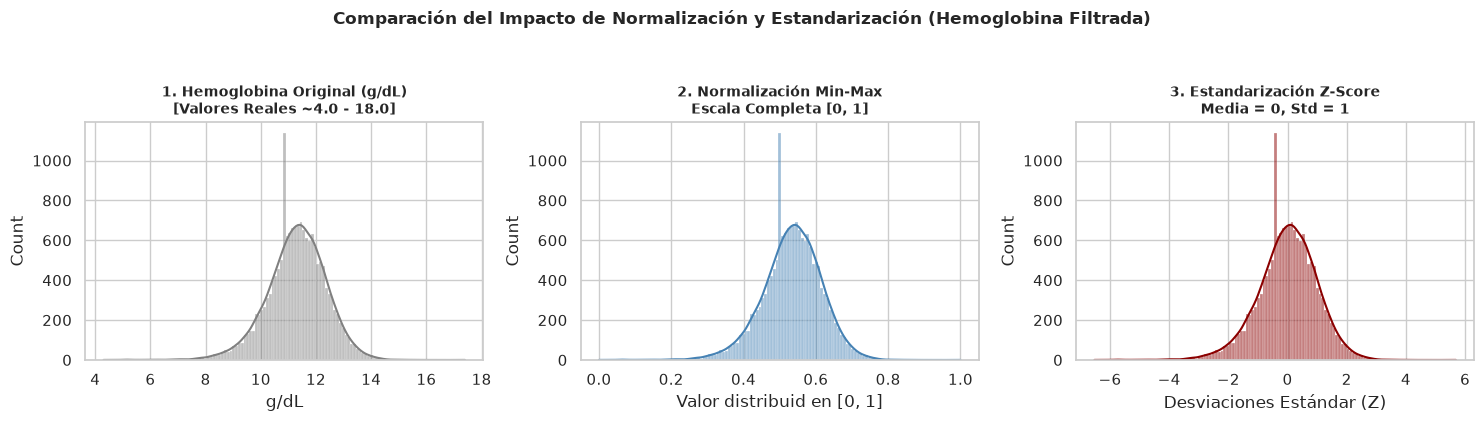

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 4. NORMALIZACIÓN Y ESTANDARIZACIÓN (ESCALADO DE VARIABLES CONTINUAS)
# =============================================================================

# 1. Asegurar limpieza de nulos/outliers en Hemoglobina (reutilizando columna previa)
if 'hemoglobina_g_dl' in df_merged.columns:
    df_merged['hemoglobina_g_dl'] = np.where(
        df_merged['hemoglobina_g_dl'] <= 25.0, 
        df_merged['hemoglobina_g_dl'], 
        np.nan
    )

# 2. Asegurar tipo numérico en Edad del Niño
if 'hw1' in df_merged.columns:
    df_merged['hw1_num'] = pd.to_numeric(df_merged['hw1'], errors='coerce')

# -----------------------------------------------------------------------------
# A) NORMALIZACIÓN (Min-Max Scaling -> Intervalo [0, 1])
# -----------------------------------------------------------------------------
# Edad del Niño
if 'hw1_num' in df_merged.columns:
    min_edad = df_merged['hw1_num'].min()
    max_edad = df_merged['hw1_num'].max()
    df_merged['edad_norm_minmax'] = (df_merged['hw1_num'] - min_edad) / (max_edad - min_edad)

# Hemoglobina (Solo datos válidos)
if 'hemoglobina_g_dl' in df_merged.columns:
    min_hb = df_merged['hemoglobina_g_dl'].min()
    max_hb = df_merged['hemoglobina_g_dl'].max()
    df_merged['hb_norm_minmax'] = (df_merged['hemoglobina_g_dl'] - min_hb) / (max_hb - min_hb)

# Edad del Jefe de Hogar (NUEVO)
if 'edad_jefe_hogar' in df_merged.columns:
    min_jefe = df_merged['edad_jefe_hogar'].min()
    max_jefe = df_merged['edad_jefe_hogar'].max()
    df_merged['edad_jefe_norm_minmax'] = (df_merged['edad_jefe_hogar'] - min_jefe) / (max_jefe - min_jefe)

# -----------------------------------------------------------------------------
# B) ESTANDARIZACIÓN (Z-Score Scaling -> Media = 0, Std = 1)
# -----------------------------------------------------------------------------
# Edad del Niño
if 'hw1_num' in df_merged.columns:
    mean_edad = df_merged['hw1_num'].mean()
    std_edad = df_merged['hw1_num'].std()
    df_merged['edad_zscore'] = (df_merged['hw1_num'] - mean_edad) / std_edad

# Hemoglobina
if 'hemoglobina_g_dl' in df_merged.columns:
    mean_hb = df_merged['hemoglobina_g_dl'].mean()
    std_hb = df_merged['hemoglobina_g_dl'].std()
    df_merged['hb_zscore'] = (df_merged['hemoglobina_g_dl'] - mean_hb) / std_hb

# Edad del Jefe de Hogar (NUEVO)
if 'edad_jefe_hogar' in df_merged.columns:
    mean_jefe = df_merged['edad_jefe_hogar'].mean()
    std_jefe = df_merged['edad_jefe_hogar'].std()
    df_merged['edad_jefe_zscore'] = (df_merged['edad_jefe_hogar'] - mean_jefe) / std_jefe

print(" Datos normalizados y estandarizados con éxito.")

# -----------------------------------------------------------------------------
# DEMOSTRACIÓN DE DATOS: TABLA COMPARATIVA
# -----------------------------------------------------------------------------
cols_escaladas = [
    'hw1_num', 'edad_norm_minmax', 'edad_zscore',
    'hemoglobina_g_dl', 'hb_norm_minmax', 'hb_zscore'
]

print("## TABLA: Muestra comparativa de Variables (Sin códigos 99.9)###")
display(df_merged[cols_escaladas].dropna().head(8).round(4))

# -----------------------------------------------------------------------------
# DEMOSTRACIÓN GRÁFICA CORREGIDA
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Original
sns.histplot(df_merged['hemoglobina_g_dl'].dropna(), kde=True, ax=axes[0], color='gray')
axes[0].set_title('1. Hemoglobina Original (g/dL)\n[Valores Reales ~4.0 - 18.0]', fontsize=10, fontweight='bold')
axes[0].set_xlabel('g/dL')

# 2. Normalización Min-Max
sns.histplot(df_merged['hb_norm_minmax'].dropna(), kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('2. Normalización Min-Max\nEscala Completa [0, 1]', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Valor distribuid en [0, 1]')

# 3. Estandarización Z-Score
sns.histplot(df_merged['hb_zscore'].dropna(), kde=True, ax=axes[2], color='darkred')
axes[2].set_title('3. Estandarización Z-Score\nMedia = 0, Std = 1', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Desviaciones Estándar (Z)')

plt.suptitle('Comparación del Impacto de Normalización y Estandarización (Hemoglobina Filtrada)', fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Validación automatizada

In [64]:
import sys
import subprocess

# 1. VERIFICACIÓN E INSTALACIÓN AUTOMÁTICA DE PANDERA
try:
    import pandera as pa_main
    import pandera.pandas as pa
except ImportError:
    print("Pandera no detectado. Instalando automáticamente...")
    subprocess.run([sys.executable, "-m", "pip", "install", "pandera", "-q"])
    import pandera as pa_main
    import pandera.pandas as pa
    print("Pandera instalado e importado con éxito.")

# 2. IMPORTACIONES GENERALES DEL PROYECTO
import pandas as pd
import numpy as np
from pandera.pandas import Column, Check, DataFrameSchema
import os
import logging
from datetime import datetime

print(f"Entorno listo. Pandera v{pa_main.__version__} cargado correctamente.")

Entorno listo. Pandera v0.32.1 cargado correctamente.


### Configuración de Logs 

In [65]:
import os
import logging

# =============================================================================
# CONFIGURACIÓN DE LOGS PARA JUPYTER NOTEBOOK (DATA GOVERNANCE & AUDITORÍA)
# =============================================================================

# 1. Obtención de la ruta raíz del proyecto (subiendo un nivel desde 'notebooks/')
# Funciona tanto si usas os.getcwd() como si defines la ruta dinámica sin __file__
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

# 2. Creación dinámica de la carpeta 'logs' en la raíz
DIR_LOGS = os.path.join(BASE_DIR, "logs")
os.makedirs(DIR_LOGS, exist_ok=True)
archivo_log = os.path.join(DIR_LOGS, "autocorreccion_calidad.log")

# 3. Limpieza de Handlers previos (Crucial para Notebooks al re-ejecutar la celda)
root_logger = logging.getLogger()
for handler in root_logger.handlers[:]:
    root_logger.removeHandler(handler)

# 4. Configuración centralizada de logging con salida dual (Archivo + Consola de Jupyter)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(name)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    handlers=[
        logging.FileHandler(archivo_log, encoding='utf-8', mode='a'), # Guarda en archivo
        logging.StreamHandler()                                       # Imprime en la salida de la celda
    ],
    force=True
)

logger = logging.getLogger("DataGovernanceLogger")

logger.info("=" * 80)
logger.info("INICIO DE SESIÓN EN JUPYTER | Fase de Gobernanza de Datos y Calidad")
logger.info("=" * 80)

print(f" Sistema de Logging activo. Registrando en:\n   {archivo_log}")

2026-08-15 08:02:37 | INFO | DataGovernanceLogger | ================================================================================
2026-08-15 08:02:37 | INFO | DataGovernanceLogger | INICIO DE SESIÓN EN JUPYTER | Fase de Gobernanza de Datos y Calidad
2026-08-15 08:02:37 | INFO | DataGovernanceLogger | ================================================================================


 Sistema de Logging activo. Registrando en:
   c:\ESTUDIOS\CIBERTEC\Ciclo4_LenguajeCienciaDatos2\T1_grupal_V3\PROYECTO-AVANCE\PROYECTO-AVANCE\logs\autocorreccion_calidad.log


### Carga de Datos y Definición del Esquema Pandera

In [66]:

import os
import pandas as pd
import pandera.pandas as pa
from pandera.pandas import Column, Check, DataFrameSchema

# =============================================================================
# GUARDADO Y CONFIGURACIÓN DE ESQUEMA PANDERA (.ipynb)
# =============================================================================

# 1. Resolución dinámica de la carpeta 'data/datos_normalizados_parquet' desde 'notebooks/'
RUTA_ACTUAL = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(RUTA_ACTUAL, "..")) if os.path.basename(RUTA_ACTUAL) == "notebooks" else RUTA_ACTUAL

DIR_PARQUET = os.path.abspath(os.path.join(BASE_DIR, "data", "processed"))
os.makedirs(DIR_PARQUET, exist_ok=True)  # Crea la carpeta 'processed' si no existe

path_parquet = os.path.join(DIR_PARQUET, "endes_2025_nutricion_m1638_enriquecido.parquet")

# 2. Guardar el DataFrame con las 4 técnicas aplicadas
df_merged.to_parquet(path_parquet, index=False, engine='pyarrow', compression='snappy')
print(f" Dataset enriquecido guardado exitosamente en:\n   {path_parquet}")

# 3. Asignar directamente para validación (se evitan operaciones I/O innecesarias)
df_enriquecido = df_merged.copy()

# 4. Definición del Esquema Pandera
esquema_endes = DataFrameSchema(
    columns={
        "id1": Column(pa.Int64, nullable=True, checks=Check.greater_than_or_equal_to(2000)),
        "caseid": Column(pa.String, nullable=False, checks=Check.str_length(min_value=1)),
        "hwidx": Column(pa.Int64, nullable=False, checks=Check.greater_than_or_equal_to(1)),
        "ubigeo": Column(pa.Int64, nullable=True),
        "v190": Column(pa.Int64, nullable=True, checks=Check.in_range(1, 5)), 
        "orden_niño": Column(pa.Int64, nullable=True, checks=Check.greater_than_or_equal_to(1)),

        # Variables de Anemia
        "tiene_anemia": Column(pa.Int64, nullable=False, checks=Check.isin([0, 1])),
        "desc_anemia_nivel": Column(
            pa.String, 
            nullable=True, 
            checks=Check.isin(['1. Grave', '2. Moderada', '3. Leve', '4. Sin Anemia', 'Sin dato'])
        ),
        "tipo_orden_nacimiento": Column(
            pa.String, 
            nullable=True, 
            checks=Check.isin(['1. Primogénito', '2. Segundo/Tercer Hijo', '3. Cuarto a más'])
        ),

        # Variables Territoriales y Agregadas
        "codigo_dep": Column(pa.String, nullable=False, checks=Check.str_length(min_value=2, max_value=2)),
        "nombre_departamento": Column(pa.String, nullable=False),
        "total_evaluados_dep": Column(pa.Int64, nullable=True, checks=Check.greater_than(0)),
        "total_anemia_dep": Column(pa.Int64, nullable=True, checks=Check.greater_than_or_equal_to(0)),
        "pct_anemia_dep": Column(pa.Float64, nullable=True, checks=Check.in_range(min_value=0.0, max_value=100.0)),

        # Variables Clínicas y Discretizaciones (Soporte para pa.Category o pa.Object)
        "hemoglobina_g_dl": Column(
            pa.Float64, 
            nullable=True, 
            checks=Check.in_range(min_value=2.0, max_value=25.0)
        ),
        "rango_edad_child": Column(
            pa.Category, 
            nullable=True, 
            checks=Check.isin([
                '1. 0-11 meses (Lactantes)', 
                '2. 12-23 meses (Caminadores)', 
                '3. 24-59 meses (Preescolares)'
            ])
        ),
        "rango_hemoglobina": Column(
            pa.Category, 
            nullable=True, 
            checks=Check.isin([
                '1. Anemia Severa (<7.0 g/dL)', 
                '2. Anemia Moderada (7.0-9.9 g/dL)', 
                '3. Anemia Leve (10.0-10.9 g/dL)', 
                '4. Sin Anemia (>=11.0 g/dL)'
            ])
        ),
        # Nuevas variables integradas
        "nivel_educativo_agrupado": Column(pa.String, nullable=True),
        "es_jefatura_femenina": Column(pa.Int64, nullable=True, checks=Check.isin([0, 1]))
    },
    strict=False, 
    coerce=True   
)

print(f"Dataset listo en memoria ({len(df_enriquecido):,} filas) y esquema Pandera configurado.")

 Dataset enriquecido guardado exitosamente en:
   c:\ESTUDIOS\CIBERTEC\Ciclo4_LenguajeCienciaDatos2\T1_grupal_V3\PROYECTO-AVANCE\PROYECTO-AVANCE\data\processed\endes_2025_nutricion_m1638_enriquecido.parquet
Dataset listo en memoria (18,841 filas) y esquema Pandera configurado.


### Ejecución, Remediación Vectorización y auditoría

In [67]:
import os
import numpy as np
import pandas as pd
import pandera as pa

# =============================================================================
# EJECUCIÓN, REMEDIACIÓN VECTORIZADA Y AUDITORÍA (.ipynb)
# =============================================================================

# 1. Definición segura de la ruta de logs desde 'notebooks/'
RUTA_ACTUAL = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(RUTA_ACTUAL, "..")) if os.path.basename(RUTA_ACTUAL) == "notebooks" else RUTA_ACTUAL

DIR_LOGS = os.path.join(BASE_DIR, "logs")
os.makedirs(DIR_LOGS, exist_ok=True)
archivo_log = os.path.join(DIR_LOGS, "autocorreccion_calidad.log")

# 2. Validación con Pandera
try:
    df_validado = esquema_endes.validate(df_enriquecido, lazy=True)
    print("=" * 85)
    print("VALIDACIÓN EXITOSA: El dataset no presentó inconsistencias de calidad.")
    print("=" * 85)
    logger.info("VALIDACION_OK | El dataset paso las reglas de calidad sin inconsistencias.")

except pa.errors.SchemaErrors as err:
    print("=" * 85)
    print(" WARNING: INCONSISTENCIAS DETECTADAS POR PANDERA")
    print("=" * 85)
    
    # Reporte de inconsistencias (display está garantizado en Jupyter)
    resumen_errores = err.failure_cases[['column', 'check', 'failure_case']].drop_duplicates()
    display(resumen_errores)
    print("-" * 85)
    
    logger.warning(f"INCONSISTENCIA_DETECTADA | Columnas con error: {resumen_errores['column'].unique().tolist()}")
    
    # Remedación vectorizada sobre valores fuera de rango de hemoglobina
    if 'hemoglobina_g_dl' in df_enriquecido.columns:
        registros_afectados = (df_enriquecido['hemoglobina_g_dl'] > 25.0).sum()
        
        if registros_afectados > 0:
            df_enriquecido['hemoglobina_g_dl'] = np.where(
                df_enriquecido['hemoglobina_g_dl'] <= 25.0, 
                df_enriquecido['hemoglobina_g_dl'], 
                np.nan
            )
            
            # Guardado de cambios
            df_enriquecido.to_parquet(path_parquet, index=False, engine='pyarrow', compression='snappy')
            
            mensaje_log = (
                f"REMEDIACION_EXITOSA | Campo: 'hemoglobina_g_dl' | "
                f"Registros corregidos: {registros_afectados:,} | "
                f"Accion: Conversion de codigos de no respuesta (>25.0) a 'NaN'"
            )
            logger.info(mensaje_log)
            
            print(" ACCIÓN CORRECTIVA APLICADA Y LOGGEADA:")
            print(f"   ✔ Se corrigieron {registros_afectados:,} registros anómalos en 'hemoglobina_g_dl'.")
            print(f"   ✔ Evento registrado en: '{archivo_log}'")
            print("-" * 85)
            
            # Re-validación tras la limpieza
            df_validado = esquema_endes.validate(df_enriquecido, lazy=True)
            print("RE-VALIDACIÓN EXITOSA: Dataset 100% consistente y limpio.")
            print("=" * 85)
            logger.info("REVALIDACION_OK | Dataset 100% limpio y validado tras la remediacion.")

# 3. Mostrar últimas entradas de la bitácora en celda
print("\n ÚLTIMAS ENTRADAS DE BITÁCORA (logs/autocorreccion_calidad.log):")
print("-" * 85)
if os.path.exists(archivo_log):
    with open(archivo_log, "r", encoding="utf-8") as f:
        lineas = f.readlines()
        for linea in lineas[-5:]:
            print(linea.strip())

2026-08-15 08:02:38 | INFO | DataGovernanceLogger | VALIDACION_OK | El dataset paso las reglas de calidad sin inconsistencias.


VALIDACIÓN EXITOSA: El dataset no presentó inconsistencias de calidad.

 ÚLTIMAS ENTRADAS DE BITÁCORA (logs/autocorreccion_calidad.log):
-------------------------------------------------------------------------------------
2026-08-15 04:40:26 | INFO | GUARDADO_FINAL_OK | Archivo: 'endes_2025_nutricion_m1638_enriquecido.parquet' | Ubicacion: 'data/processed/' | Filas: 18,841 | Columnas: 77 | Tamaño en memoria: 9.59 MB (33.8% ahorro)
2026-08-15 08:02:37 | INFO | DataGovernanceLogger | ================================================================================
2026-08-15 08:02:37 | INFO | DataGovernanceLogger | INICIO DE SESIÓN EN JUPYTER | Fase de Gobernanza de Datos y Calidad
2026-08-15 08:02:37 | INFO | DataGovernanceLogger | ================================================================================
2026-08-15 08:02:38 | INFO | DataGovernanceLogger | VALIDACION_OK | El dataset paso las reglas de calidad sin inconsistencias.


## Optimización de Memoria y Tiempos de Ejecución

In [68]:
# =============================================================================
# OPTIMIZACIÓN DE MEMORIA RAM: DOWNCASTING Y VECTORIZACIÓN
# =============================================================================

df_optimizado = df_enriquecido.copy()
memoria_inicial_mb = df_enriquecido.memory_usage(deep=True).sum() / (1024 ** 2)

# -----------------------------------------------------------------------------
# A) DOWNCASTING NUMÉRICO SEGURO Y CORREGIDO
# -----------------------------------------------------------------------------
# int8: -128 a 127
cols_int8 = ['tiene_anemia', 'v190', 'hwidx', 'orden_niño', 'es_jefatura_femenina']

# int16: -32,768 a 32,767
cols_int16 = ['id1', 'total_evaluados_dep', 'total_anemia_dep', 'evaluados_dep_edu', 'anemia_dep_edu']

# int32: Hasta 2,147,483,647 (UBIGEO corregido aquí para evitar overflow)
cols_int32 = ['ubigeo', 'edad_jefe_hogar']

for col in cols_int8:
    if col in df_optimizado.columns:
        df_optimizado[col] = pd.to_numeric(df_optimizado[col], errors='coerce').astype('Int8')

for col in cols_int16:
    if col in df_optimizado.columns:
        df_optimizado[col] = pd.to_numeric(df_optimizado[col], errors='coerce').astype('Int16')

for col in cols_int32:
    if col in df_optimizado.columns:
        df_optimizado[col] = pd.to_numeric(df_optimizado[col], errors='coerce').astype('Int32')

# Downcasting de Flotantes (float64 -> float32)
cols_float32 = [
    'pct_anemia_dep', 'hemoglobina_g_dl', 'prom_hb_edad_meses', 
    'pct_anemia_dep_edu', 'pct_anemia_quintil_riqueza'
]
for col in cols_float32:
    if col in df_optimizado.columns:
        df_optimizado[col] = pd.to_numeric(df_optimizado[col], errors='coerce').astype('float32')

# -----------------------------------------------------------------------------
# B) CONVERSIÓN DE CADENAS / TEXTO A 'CATEGORY'
# -----------------------------------------------------------------------------
cols_categoricas = [
    'codigo_dep', 'nombre_departamento', 'desc_anemia_nivel', 
    'tipo_orden_nacimiento', 'rango_edad_child', 'rango_hemoglobina',
    'desc_logro_educativo', 'desc_relacion_jefe', 'desc_sexo_jefe',
    'nivel_educativo_agrupado', 'rango_edad_jefe_hogar',
    'rango_desnutricion_cronica', 'rango_peso_talla_oms'
]

for col in cols_categoricas:
    if col in df_optimizado.columns:
        df_optimizado[col] = df_optimizado[col].astype('category')

memoria_final_mb = df_optimizado.memory_usage(deep=True).sum() / (1024 ** 2)

## Comparación de Memoria Antes y Después de Optimizar

In [69]:
# =============================================================================
# COMPARACIÓN DE MEMORIA Y RENDIMIENTO
# =============================================================================

reduccion_mb = memoria_inicial_mb - memoria_final_mb
porcentaje_ahorro = (reduccion_mb / memoria_inicial_mb) * 100

print("=" * 85)
print(" RESUMEN EJECUTIVO DE OPTIMIZACIÓN DE MEMORIA RAM")
print("=" * 85)
print(f" Memoria consumida ANTES de optimizar: {memoria_inicial_mb:.2f} MB")
print(f" Memoria consumida DESPUÉS de optimizar: {memoria_final_mb:.2f} MB")
print(f" Reducción Total de Memoria:              {reduccion_mb:.2f} MB")
print(f" Eficiencia Lograda:                       {porcentaje_ahorro:.2f}% de Ahorro")
print("=" * 85 + "\n")

# Matriz por columna evaluada
comparativa_cols = []
cols_evaluadas = cols_int8 + cols_int16 + cols_int32 + cols_float32 + cols_categoricas

for col in cols_evaluadas:
    if col in df_enriquecido.columns:
        mem_antes_kb = df_enriquecido[col].memory_usage(deep=True) / 1024
        mem_despues_kb = df_optimizado[col].memory_usage(deep=True) / 1024
        ahorro_col_pct = ((mem_antes_kb - mem_despues_kb) / mem_antes_kb) * 100
        
        comparativa_cols.append({
            'Campo / Columna': col,
            'Tipo Original': str(df_enriquecido[col].dtype),
            'Tipo Optimizado': str(df_optimizado[col].dtype),
            'Memoria Antes (KB)': round(mem_antes_kb, 2),
            'Memoria Después (KB)': round(mem_despues_kb, 2),
            '% Ahorro Memoria': f"{ahorro_col_pct:.1f}%"
        })

df_reporte_memoria = pd.DataFrame(comparativa_cols)

print("DETALLE DE OPTIMIZACIÓN POR CAMPO:")
try:
    display(df_reporte_memoria)
except NameError:
    print(df_reporte_memoria)

 RESUMEN EJECUTIVO DE OPTIMIZACIÓN DE MEMORIA RAM
 Memoria consumida ANTES de optimizar: 14.51 MB
 Memoria consumida DESPUÉS de optimizar: 9.60 MB
 Reducción Total de Memoria:              4.91 MB
 Eficiencia Lograda:                       33.84% de Ahorro

DETALLE DE OPTIMIZACIÓN POR CAMPO:


,Campo / Columna,Tipo Original,Tipo Optimizado,Memoria Antes (KB),Memoria Después (KB),% Ahorro Memoria
0,tiene_anemia,int64,Int8,147.32,36.93,74.9%
1,v190,int64,Int8,147.32,36.93,74.9%
2,hwidx,int64,Int8,147.32,36.93,74.9%
3,orden_niño,int64,Int8,147.32,36.93,74.9%
4,es_jefatura_femenina,int64,Int8,147.32,36.93,74.9%
5,id1,int64,Int16,147.32,55.33,62.4%
6,total_evaluados_dep,int64,Int16,147.32,55.33,62.4%
7,total_anemia_dep,int64,Int16,147.32,55.33,62.4%
8,evaluados_dep_edu,int64,Int16,147.32,55.33,62.4%
9,anemia_dep_edu,int64,Int16,147.32,55.33,62.4%


### ALMACENAMIENTO FINAL DEL DATASET OPTIMIZADO Y LIMPIO

In [70]:
import os

# =============================================================================
# ALMACENAMIENTO FINAL DEL DATASET OPTIMIZADO Y AUDITORÍA (.ipynb)
# =============================================================================

# 1. Asegurar la ruta dinámica a 'data/processed' (si no estuviese definida previamente)
if 'path_parquet' not in locals():
    RUTA_ACTUAL = os.getcwd()
    BASE_DIR = os.path.abspath(os.path.join(RUTA_ACTUAL, "..")) if os.path.basename(RUTA_ACTUAL) == "notebooks" else RUTA_ACTUAL
    DIR_PROCESSED = os.path.join(BASE_DIR, "data", "processed")
    os.makedirs(DIR_PROCESSED, exist_ok=True)
    path_parquet = os.path.join(DIR_PROCESSED, "endes_2025_nutricion_m1638_enriquecido.parquet")

# 2. Persistir el dataset optimizado en el archivo Parquet
df_optimizado.to_parquet(
    path_parquet, 
    index=False, 
    engine='pyarrow', 
    compression='snappy'
)

# 3. Recuperar métricas de memoria de forma segura (por ejecuciones aisladas de la celda)
mem_mb = memoria_final_mb if 'memoria_final_mb' in locals() else df_optimizado.memory_usage(deep=True).sum() / (1024 ** 2)
ahorro_pct = porcentaje_ahorro if 'porcentaje_ahorro' in locals() else 0.0

# 4. Registrar el evento final en la bitácora de Gobernanza
if 'logger' in locals():
    logger.info(
        f"GUARDADO_FINAL_OK | Archivo: '{os.path.basename(path_parquet)}' | "
        f"Ruta: 'data/processed/' | "
        f"Filas: {len(df_optimizado):,} | Columnas: {len(df_optimizado.columns)} | "
        f"Tamaño en RAM: {mem_mb:.2f} MB ({ahorro_pct:.1f}% ahorro)"
    )

# 5. Resumen Ejecutivo impreso en la celda del cuaderno
print("=" * 85)
print(" PROCESO COMPLETADO Y PIPELINE CONCLUIDO CON ÉXITO")
print("=" * 85)
print(f" Dataset final optimizado guardado en:\n   {path_parquet}")
print(f" Consumo de RAM optimizado a: {mem_mb:.2f} MB")
if 'archivo_log' in locals() and os.path.exists(archivo_log):
    print(f" Eventos de auditoría registrados en: '{archivo_log}'")
print("=" * 85)

2026-08-15 08:02:38 | INFO | DataGovernanceLogger | GUARDADO_FINAL_OK | Archivo: 'endes_2025_nutricion_m1638_enriquecido.parquet' | Ruta: 'data/processed/' | Filas: 18,841 | Columnas: 77 | Tamaño en RAM: 9.60 MB (33.8% ahorro)


 PROCESO COMPLETADO Y PIPELINE CONCLUIDO CON ÉXITO
 Dataset final optimizado guardado en:
   c:\ESTUDIOS\CIBERTEC\Ciclo4_LenguajeCienciaDatos2\T1_grupal_V3\PROYECTO-AVANCE\PROYECTO-AVANCE\data\processed\endes_2025_nutricion_m1638_enriquecido.parquet
 Consumo de RAM optimizado a: 9.60 MB
 Eventos de auditoría registrados en: 'c:\ESTUDIOS\CIBERTEC\Ciclo4_LenguajeCienciaDatos2\T1_grupal_V3\PROYECTO-AVANCE\PROYECTO-AVANCE\logs\autocorreccion_calidad.log'
